To run, save the employee_stress_dataset_2000.csv to your google drive.         
*synthetic dataset. Not all findings may be accurate. (Tho, I haven't displayed findings that go against common sense/intiution).        
### Import libraries for analysis of stress, job satisfaction levels.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import drive

drive.mount('/content/drive')

# Imports for CSV handling, plotting, and linear regression
import matplotlib.pyplot as plt

# scikit-learn for modelling

# Notebook display settings
%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams.update({"figure.figsize": (8, 6)})

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Import CSV files and save them as pd dataframe

In [3]:
from IPython.display import display
csv_path = "/content/drive/MyDrive/employee_stress_dataset_2000.csv"

df = pd.read_csv(csv_path)
display(df.head(5))
print("Loaded", len(df), "rows and", len(df.columns), "columns")
print("Top 5 columns:", df.columns.tolist()[:5])

,Employee_ID,Age,Gender,Department,Job_Role,Work_Experience,Work_Hours_per_Week,Remote_Work,Workload_Score,Job_Satisfaction,Sleep_Hours,Physical_Activity_Hrs,Caffeine_Intake,Stress_Level,Mental_Health_Score
0,E0001,50,Male,Finance,Intern,24,48,Yes,3,2,6.3,1.8,1,3.5,68.7
1,E0002,36,Male,IT,Team Lead,25,30,Yes,7,4,4.1,1.7,1,7.0,48.4
2,E0003,29,Male,Finance,Intern,29,69,Yes,7,4,5.9,0.7,4,5.1,61.2
3,E0004,42,Female,Finance,Team Lead,15,61,No,8,3,7.9,1.1,6,7.4,40.2
4,E0005,40,Female,Finance,Analyst,26,51,Yes,7,8,8.1,1.9,4,3.3,71.8


Loaded 2000 rows and 15 columns
Top 5 columns: ['Employee_ID', 'Age', 'Gender', 'Department', 'Job_Role']


### Comparison of relationship between stress levels vs job satisfaction.

Job_Satisfaction -> Stress_Level
  Intercept: 6.8463, Slope: -0.2881
  R^2: 0.2264, MSE: 1.9005


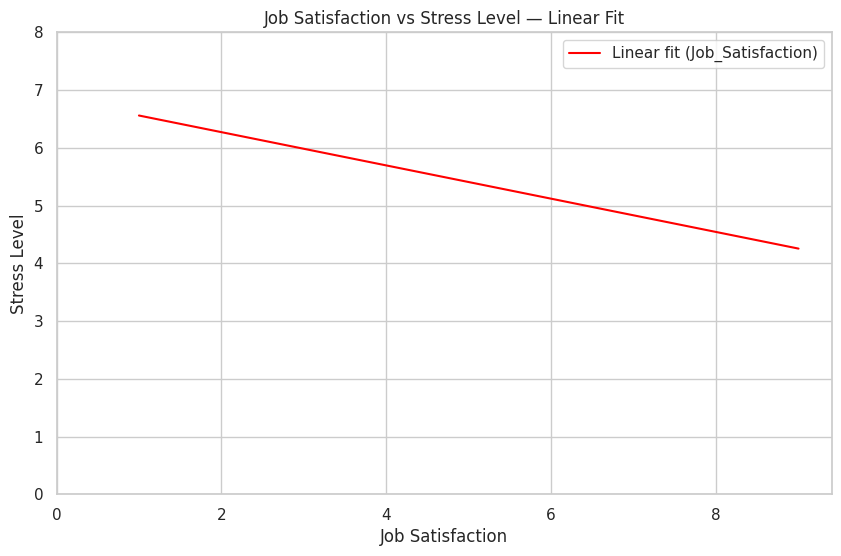

In [4]:
# Fit linear regression and display only the fitted line
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# --- Job Satisfaction -> Stress Level ---
X = df[['Job_Satisfaction']].values.reshape(-1, 1)
y = df['Stress_Level'].values

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
print("Job_Satisfaction -> Stress_Level")
print(f"  Intercept: {model.intercept_:.4f}, Slope: {model.coef_[0]:.4f}")
print(f"  R^2: {r2:.4f}, MSE: {mse:.4f}")

# Plot fitted line only (start axes at 0 and y from 0 to 8)
plt.figure(figsize=(10, 6))
xs = np.linspace(df['Job_Satisfaction'].min(), df['Job_Satisfaction'].max(), 100)
plt.plot(xs, model.predict(xs.reshape(-1, 1)), color='red', label='Linear fit (Job_Satisfaction)')
plt.xlim(left=0)
plt.ylim(0, 8)
plt.title('Job Satisfaction vs Stress Level — Linear Fit')
plt.xlabel('Job Satisfaction')
plt.ylabel('Stress Level')
plt.legend()
plt.show()


Stress levels directly influence productivity as per: https://pmc.ncbi.nlm.nih.gov/articles/PMC7889069/

### Differences by roles

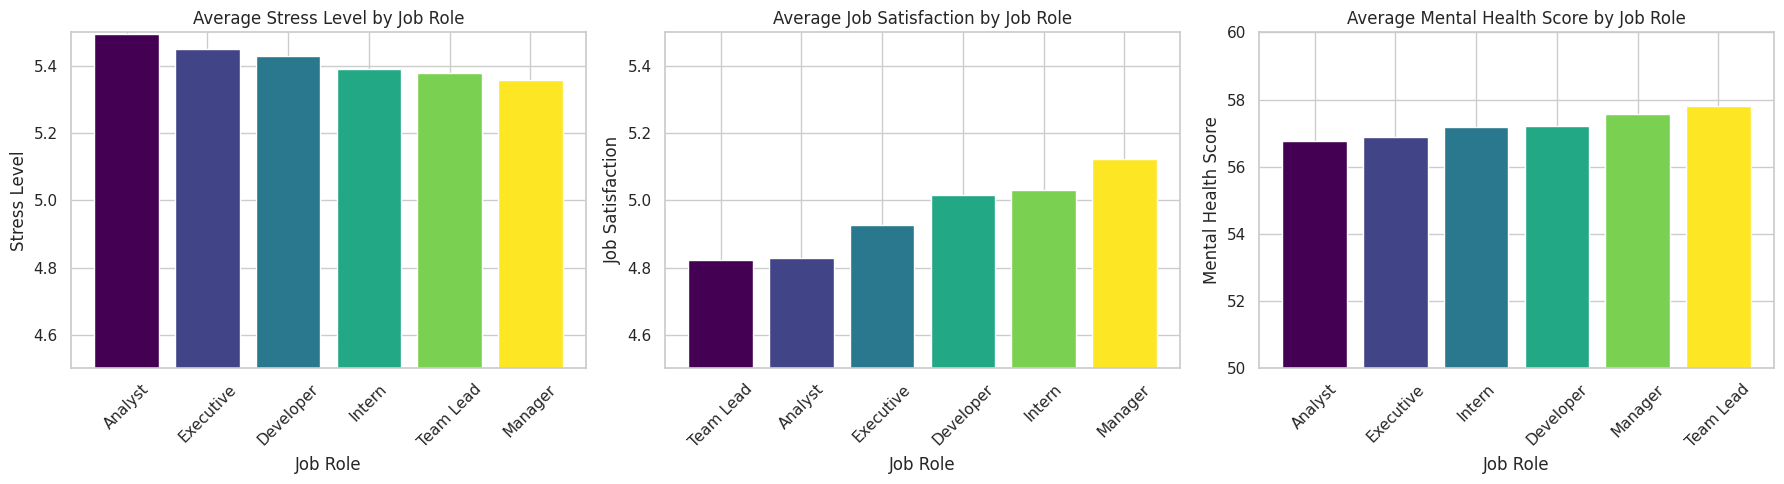

In [5]:
# Plots: mean values of Stress_Level, Job_Satisfaction, Mental_Health_Score by Job_Role
metrics = ['Stress_Level', 'Job_Satisfaction', 'Mental_Health_Score']
titles = ['Average Stress Level by Job Role', 'Average Job Satisfaction by Job Role', 'Average Mental Health Score by Job Role']

fig, axes_roles = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, title in zip(axes_roles, metrics, titles):
    # For Job_Satisfaction and Mental_Health_Score show lowest->highest; keep Stress_Level highest->lowest
    if metric in ['Job_Satisfaction', 'Mental_Health_Score']:
        order = df.groupby('Job_Role')[metric].mean().sort_values(ascending=True).index.tolist()
    else:
        order = df.groupby('Job_Role')[metric].mean().sort_values(ascending=False).index.tolist()
    means = df.groupby('Job_Role')[metric].mean().reindex(order)
    colors = plt.cm.viridis(np.linspace(0, 1, len(means)))
    ax.bar(range(len(means)), means.values, color=colors)
    ax.set_xticks(range(len(means)))
    ax.set_xticklabels(order, rotation=45)
    ax.set_title(title)
    ax.set_xlabel('Job Role')
    ax.set_ylabel(metric.replace('_', ' '))
    # Set y-limits for Stress_Level and Job_Satisfaction to [4,5]
    if metric in ['Stress_Level', 'Job_Satisfaction']:
        ax.set_ylim(4.5, 5.5)
    # Keep Mental_Health_Score zoom if desired
    if metric == 'Mental_Health_Score':
        ax.set_ylim(50, 60)

plt.tight_layout()
plt.show()

These graphs are for the ones with highest stress/job satisfaction. All these roles could use improvements, tho in different categories.

Analysts have highest stress levels, lowest job satisfaction and mental health. They are the people who would be most helped by a psycological behaviour boosting program. 

Developers/Analysists and team leads have lower team satisfaction compared to interns, which is also a metric that can be improved, mostly by lowering stress levels for these roles.

### Stress levels by departments.


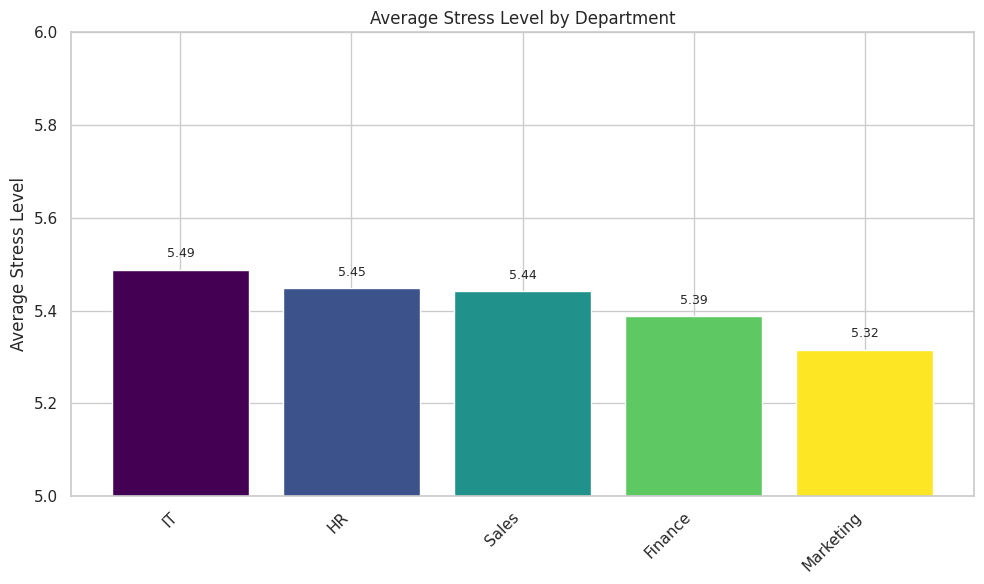

In [6]:
# Average stress level by Department
dept_means = df.groupby('Department')['Stress_Level'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(dept_means)))
plt.bar(dept_means.index, dept_means.values, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Stress Level')
plt.ylim(5, 6)
plt.title('Average Stress Level by Department')
for i, v in enumerate(dept_means.values):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


### Remote vs onsite work

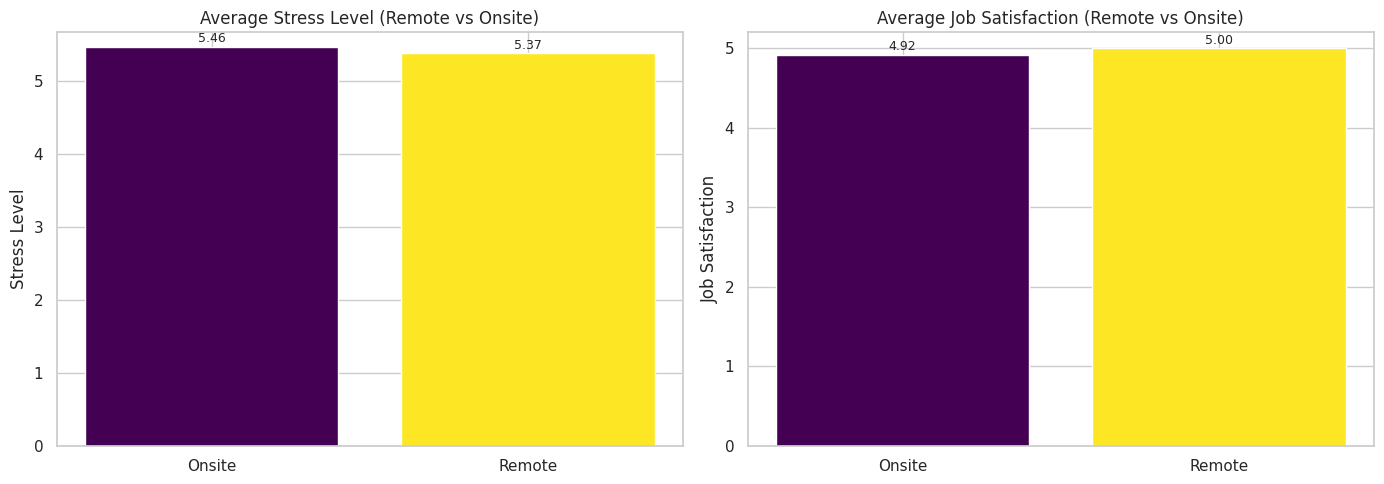

In [7]:
# Compare Remote vs Non-Remote: Stress Level and Job Satisfaction
if 'Remote_Work' not in df.columns:
    raise KeyError("Column 'Remote_Work' not found in dataframe. Available columns: {}".format(df.columns.tolist()))

# Normalize remote field to readable labels
remote_series = df['Remote_Work'].astype(str).replace({'True':'Remote','False':'Onsite','1':'Remote','0':'Onsite','yes':'Remote','no':'Onsite','Yes':'Remote','No':'Onsite'})

means = df.copy()
means['Remote_Label'] = remote_series
summary = means.groupby('Remote_Label')[['Stress_Level', 'Job_Satisfaction']].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cols = ['Stress_Level', 'Job_Satisfaction']
titles = ['Average Stress Level (Remote vs Onsite)', 'Average Job Satisfaction (Remote vs Onsite)']

for ax, col, title in zip(axes, cols, titles):
    vals = summary[col]
    labels = vals.index.tolist()
    colors = plt.cm.viridis(np.linspace(0, 1, len(vals)))
    ax.bar(labels, vals.values, color=colors)
    ax.set_title(title)
    ax.set_ylabel(col.replace('_', ' '))
    # set y-range starting from zero for clearer comparison
    ymin = 0
    ymax = vals.max() + 0.2
    ax.set_ylim(ymin, ymax)
    for i, v in enumerate(vals.values):
        ax.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


Remote workers are slightly less stressed and have slightly higher job satisfaction. But it does not reveal whether this slight change would offer any meaningful productivity gains.


### Workload compared to job satisfaction and stress levels

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


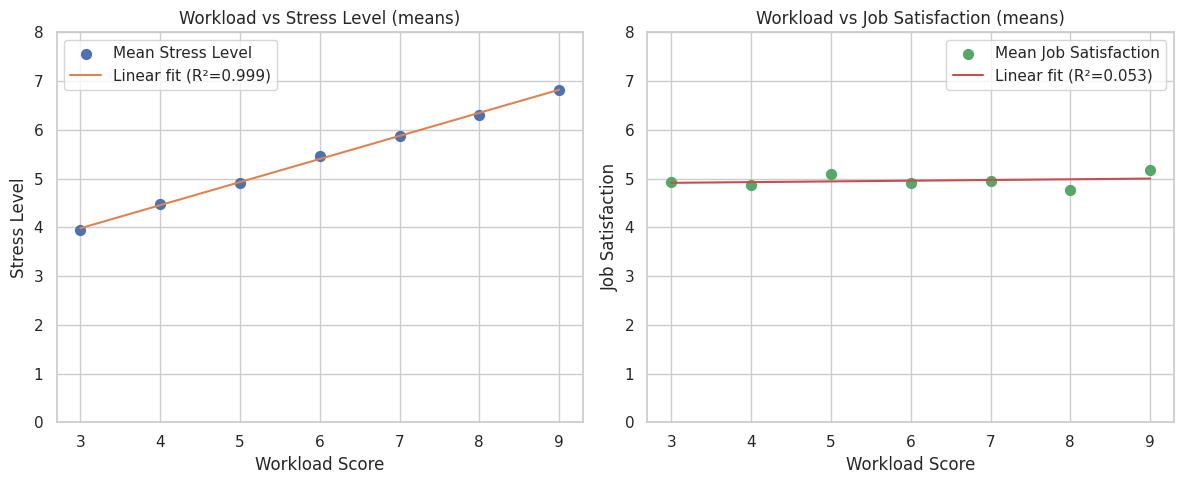

In [8]:
# Workload vs Stress Level and Job Satisfaction (means per Workload_Score + linear fits)
group = df.groupby('Workload_Score')[['Stress_Level', 'Job_Satisfaction']].mean().reset_index()

from sklearn.linear_model import LinearRegression
lr1 = LinearRegression().fit(group[['Workload_Score']], group['Stress_Level'])
lr2 = LinearRegression().fit(group[['Workload_Score']], group['Job_Satisfaction'])

xs = np.linspace(group['Workload_Score'].min(), group['Workload_Score'].max(), 200).reshape(-1, 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(group['Workload_Score'], group['Stress_Level'], color='C0', s=50, label='Mean Stress Level')
plt.plot(xs, lr1.predict(xs), color='C1', label=f"Linear fit (R²={lr1.score(group[['Workload_Score']], group['Stress_Level']):.3f})")
plt.xlabel('Workload Score')
plt.ylabel('Stress Level')
plt.title('Workload vs Stress Level (means)')
plt.ylim(0, 8)
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(group['Workload_Score'], group['Job_Satisfaction'], color='C2', s=50, label='Mean Job Satisfaction')
plt.plot(xs, lr2.predict(xs), color='C3', label=f"Linear fit (R²={lr2.score(group[['Workload_Score']], group['Job_Satisfaction']):.3f})")
plt.xlabel('Workload Score')
plt.ylabel('Job Satisfaction')
plt.title('Workload vs Job Satisfaction (means)')
plt.ylim(0, 8)
plt.legend()

plt.tight_layout()
plt.show()


We see, while lower workload leads to lower stress levels, and thus higher prouctivity, Higher workload doesn't coorlate with less job satisfaction.

### Coorlation between Mental health score and stress. (So we know that this isn't just randomly generated data.)

Mental_Health_Score -> Stress_Level
  Intercept: 12.6529, Slope: -0.1264
  R^2: 0.9241, MSE: 0.1865


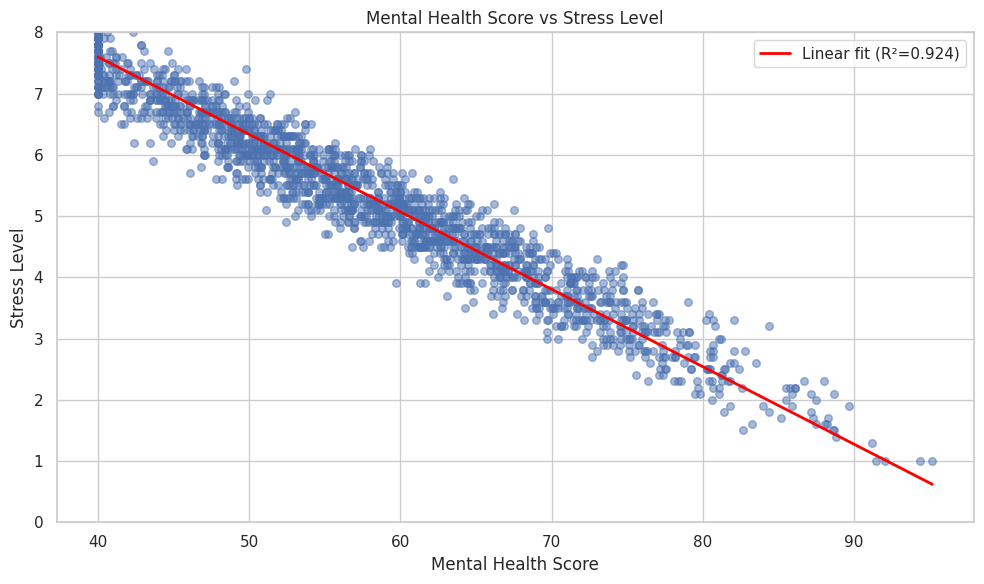

In [9]:
# Mental Health Score vs Stress Level with linear fit
X_mental = df[['Mental_Health_Score']].values.reshape(-1, 1)
y_mental = df['Stress_Level'].values

model_mental = LinearRegression()
model_mental.fit(X_mental, y_mental)
y_mental_pred = model_mental.predict(X_mental)

r2_mental = r2_score(y_mental, y_mental_pred)
mse_mental = mean_squared_error(y_mental, y_mental_pred)

print("Mental_Health_Score -> Stress_Level")
print(f"  Intercept: {model_mental.intercept_:.4f}, Slope: {model_mental.coef_[0]:.4f}")
print(f"  R^2: {r2_mental:.4f}, MSE: {mse_mental:.4f}")

# Plot with fitted line
plt.figure(figsize=(10, 6))
xs_mental = np.linspace(df['Mental_Health_Score'].min(), df['Mental_Health_Score'].max(), 100)
plt.scatter(df['Mental_Health_Score'], df['Stress_Level'], alpha=0.5, s=30)
plt.plot(xs_mental, model_mental.predict(xs_mental.reshape(-1, 1)), color='red', linewidth=2, label=f'Linear fit (R²={r2_mental:.3f})')
plt.xlabel('Mental Health Score')
plt.ylabel('Stress Level')
plt.title('Mental Health Score vs Stress Level')
plt.ylim(0, 8)
plt.legend()
plt.tight_layout()
plt.show()